In [1]:
import pandas as pd

In [2]:
movie = pd.read_csv('DataSet/movie.csv')

In [3]:
movie.shape

(27278, 3)

In [4]:
movie.columns

Index(['movieId', 'title', 'genres'], dtype='str')

In [5]:
rating = pd.read_csv('DataSet/rating.csv')

In [6]:
rating.shape

(20000263, 4)

In [7]:
rating.columns

Index(['userId', 'movieId', 'rating', 'timestamp'], dtype='str')

In [8]:
tag = pd.read_csv('DataSet/tag.csv')

In [9]:
tag.shape

(465564, 4)

In [10]:
tag.columns

Index(['userId', 'movieId', 'tag', 'timestamp'], dtype='str')

In [11]:
rating

,userId,movieId,rating,timestamp
0,1,2,3.5,2005-04-02 23:53:47
1,1,29,3.5,2005-04-02 23:31:16
2,1,32,3.5,2005-04-02 23:33:39
3,1,47,3.5,2005-04-02 23:32:07
4,1,50,3.5,2005-04-02 23:29:40
...,...,...,...,...
20000258,138493,68954,4.5,2009-11-13 15:42:00
20000259,138493,69526,4.5,2009-12-03 18:31:48
20000260,138493,69644,3.0,2009-12-07 18:10:57
20000261,138493,70286,5.0,2009-11-13 15:42:24


In [12]:
del rating['timestamp']
del tag['timestamp']

In [13]:
rating.head()

,userId,movieId,rating
0,1,2,3.5
1,1,29,3.5
2,1,32,3.5
3,1,47,3.5
4,1,50,3.5


In [14]:
tag.head()

,userId,movieId,tag
0,18,4141,Mark Waters
1,65,208,dark hero
2,65,353,dark hero
3,65,521,noir thriller
4,65,592,dark hero


In [15]:
movie.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [16]:
rating.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000263 entries, 0 to 20000262
Data columns (total 3 columns):
 #   Column   Dtype  
---  ------   -----  
 0   userId   int64  
 1   movieId  int64  
 2   rating   float64
dtypes: float64(1), int64(2)
memory usage: 457.8 MB


In [17]:
tag.info()

<class 'pandas.DataFrame'>
RangeIndex: 465564 entries, 0 to 465563
Data columns (total 3 columns):
 #   Column   Non-Null Count   Dtype
---  ------   --------------   -----
 0   userId   465564 non-null  int64
 1   movieId  465564 non-null  int64
 2   tag      465548 non-null  str  
dtypes: int64(2), str(1)
memory usage: 10.7 MB


In [18]:
movie.info()

<class 'pandas.DataFrame'>
RangeIndex: 27278 entries, 0 to 27277
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   movieId  27278 non-null  int64
 1   title    27278 non-null  str  
 2   genres   27278 non-null  str  
dtypes: int64(1), str(2)
memory usage: 639.5 KB


# 🔧 Data Cleaning: Handling Missing Data

In [19]:
movie.isnull().sum()

movieId    0
title      0
genres     0
dtype: int64

In [20]:
tag.isnull().sum()

userId      0
movieId     0
tag        16
dtype: int64

In [21]:
# tags = tags.dropna() try if not needed the drop data

In [22]:
tag['tag'].isna().sum()

np.int64(16)

In [23]:
 tag[tag['tag'].isna()] # This Are The Value Are not tag null

,userId,movieId,tag
373276,116460,123,NaN
373277,116460,346,NaN
373281,116460,1184,NaN
373288,116460,1785,NaN
373289,116460,2194,NaN
373291,116460,2691,NaN
373299,116460,4103,NaN
373301,116460,4473,NaN
373303,116460,4616,NaN
373319,116460,7624,NaN


In [51]:
mode_value = tag['tag'].mode()
print(mode_value.get(0))

sci-fi


In [55]:
tag[tag['tag'].isna()] = tag[tag['tag'].isna()].fillna(mode_value.get(0))

In [61]:
tag[373276:373278]

,userId,movieId,tag
373276,116460,123,sci-fi
373277,116460,346,sci-fi


In [62]:
tag.isna().sum()

userId     0
movieId    0
tag        0
dtype: int64

In [25]:
rating.isnull().sum()

userId     0
movieId    0
rating     0
dtype: int64

# 📈 📉 Descriptive Statistics

In [26]:
rating['rating'].describe()

count    2.000026e+07
mean     3.525529e+00
std      1.051989e+00
min      5.000000e-01
25%      3.000000e+00
50%      3.500000e+00
75%      4.000000e+00
max      5.000000e+00
Name: rating, dtype: float64

In [27]:
rating['rating'].mean()

np.float64(3.5255285642993797)

In [28]:
rating.mean()

userId     69045.872583
movieId     9041.567330
rating         3.525529
dtype: float64

In [29]:
rating['rating'].mode()

0    4.0
Name: rating, dtype: float64

In [30]:
rating['rating'].median()

np.float64(3.5)

In [31]:
tag.iloc[[0,11,500]]

,userId,movieId,tag
0,18,4141,Mark Waters
11,65,1783,noir thriller
500,342,55908,entirely dialogue


In [32]:
rating.corr()

,userId,movieId,rating
userId,1.000000,-0.000850,0.001175
movieId,-0.000850,1.000000,0.002606
rating,0.001175,0.002606,1.000000


# ▩ DataFrames

In [33]:
rating.iloc[1]

userId      1.0
movieId    29.0
rating      3.5
Name: 1, dtype: float64

In [34]:
row_0 = tag.iloc[3]
row_0

userId                65
movieId              521
tag        noir thriller
Name: 3, dtype: object

In [35]:
row_0.index

Index(['userId', 'movieId', 'tag'], dtype='str')

In [36]:
row_0['userId']

np.int64(65)

In [37]:
row_0['tag']

'noir thriller'

In [38]:
rating[3:5]

,userId,movieId,rating
3,1,47,3.5
4,1,50,3.5


In [39]:
rating[250:275]

,userId,movieId,rating
250,3,440,3.0
251,3,442,3.0
252,3,457,5.0
253,3,480,5.0
254,3,490,5.0
255,3,512,2.0
256,3,541,5.0
257,3,589,4.0
258,3,593,5.0
259,3,610,4.0


# 📊 Data Visualization

In [66]:
import matplotlib.pyplot as plt

array([[<Axes: title={'center': 'rating'}>]], dtype=object)

<Figure size 800x800 with 0 Axes>

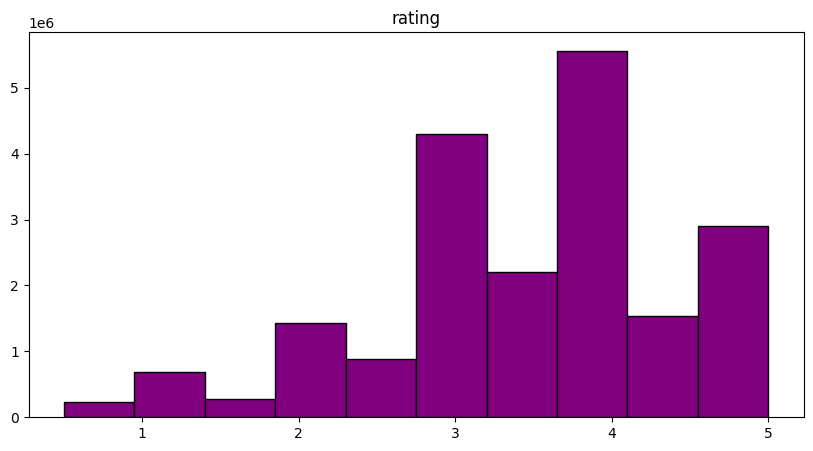

In [95]:
%matplotlib inline

plt.figure(figsize=(8, 8))
rating.hist(column='rating', figsize=(10,5),grid=False,edgecolor='black',color='purple')

<Axes: >

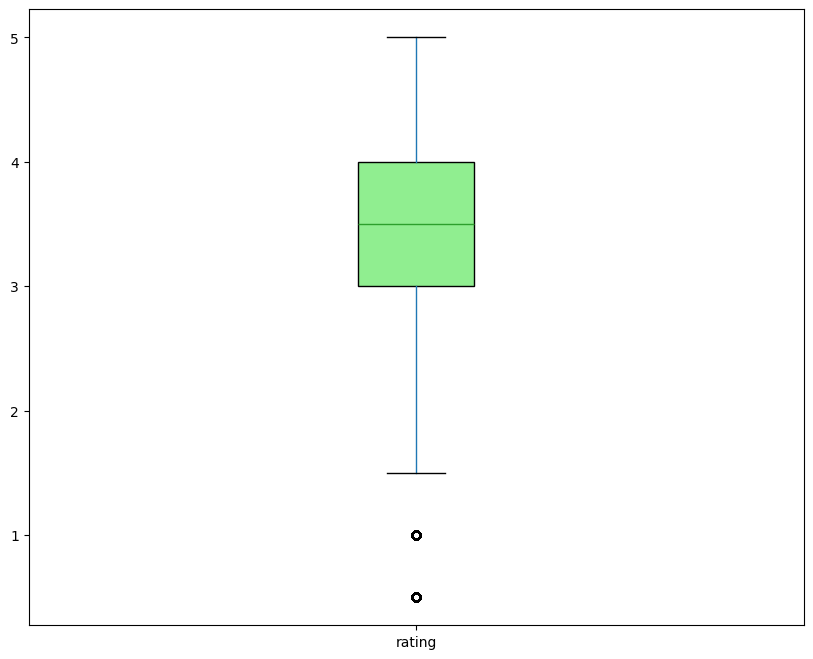

In [96]:
rating.boxplot(column='rating', figsize=(10,8),grid=False, patch_artist=True, boxprops=dict(facecolor="lightgreen"))

# 📤 Slicing Out Columns

In [98]:
tag['tag'].head()

0      Mark Waters
1        dark hero
2        dark hero
3    noir thriller
4        dark hero
Name: tag, dtype: str

In [100]:
movie[['title','genres']].head()

,title,genres
0,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,Jumanji (1995),Adventure|Children|Fantasy
2,Grumpier Old Men (1995),Comedy|Romance
3,Waiting to Exhale (1995),Comedy|Drama|Romance
4,Father of the Bride Part II (1995),Comedy


In [101]:
rating[-10:]

,userId,movieId,rating
20000253,138493,60816,4.5
20000254,138493,61160,4.0
20000255,138493,65682,4.5
20000256,138493,66762,4.5
20000257,138493,68319,4.5
20000258,138493,68954,4.5
20000259,138493,69526,4.5
20000260,138493,69644,3.0
20000261,138493,70286,5.0
20000262,138493,71619,2.5


In [103]:
tag_counts = tag['tag'].value_counts() # --> Return a Series containing the frequency of each distinct row in the DataFrame.
tag_counts[-10:]

tag
Roland JoffÃ©                                                           1
Seu Jorge                                                               1
Michel Audiard                                                          1
French film                                                             1
Clouseau                                                                1
Disguises                                                               1
retarted                                                                1
circle k                                                                1
This movie should have been called \\"How Cocaine Ruined Disney\"\""    1
topless scene                                                           1
Name: count, dtype: int64

<Axes: xlabel='tag'>

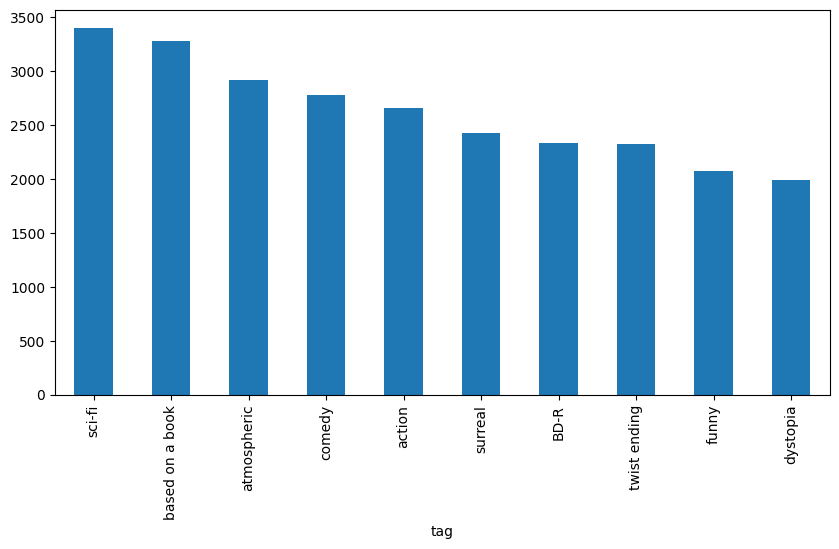

In [104]:
tag_counts[:10].plot(kind='bar', figsize=(10,5))

# 🎣 Filters for Selecting Rows

In [110]:
is_highly_rated = rating['rating'] >= 5.0
rating[is_highly_rated][0:10]

,userId,movieId,rating
131,1,4993,5.0
142,1,5952,5.0
158,1,7153,5.0
170,1,8507,5.0
176,2,62,5.0
177,2,70,5.0
180,2,260,5.0
181,2,266,5.0
183,2,480,5.0
184,2,541,5.0


In [111]:
is_action= movie['genres'].str.contains('Action')
movie[is_action][5:15]

,movieId,title,genres
22,23,Assassins (1995),Action|Crime|Thriller
41,42,Dead Presidents (1995),Action|Crime|Drama
43,44,Mortal Kombat (1995),Action|Adventure|Fantasy
50,51,Guardian Angel (1994),Action|Drama|Thriller
65,66,Lawnmower Man 2: Beyond Cyberspace (1996),Action|Sci-Fi|Thriller
69,70,From Dusk Till Dawn (1996),Action|Comedy|Horror|Thriller
70,71,Fair Game (1995),Action
75,76,Screamers (1995),Action|Sci-Fi|Thriller
77,78,"Crossing Guard, The (1995)",Action|Crime|Drama|Thriller
85,86,White Squall (1996),Action|Adventure|Drama


In [112]:
movie[is_action].head(15)

,movieId,title,genres
5,6,Heat (1995),Action|Crime|Thriller
8,9,Sudden Death (1995),Action
9,10,GoldenEye (1995),Action|Adventure|Thriller
14,15,Cutthroat Island (1995),Action|Adventure|Romance
19,20,Money Train (1995),Action|Comedy|Crime|Drama|Thriller
22,23,Assassins (1995),Action|Crime|Thriller
41,42,Dead Presidents (1995),Action|Crime|Drama
43,44,Mortal Kombat (1995),Action|Adventure|Fantasy
50,51,Guardian Angel (1994),Action|Drama|Thriller
65,66,Lawnmower Man 2: Beyond Cyberspace (1996),Action|Sci-Fi|Thriller


# 👥 Group By and Aggregate

In [113]:
ratings_count = rating[['movieId','rating']].groupby('rating').count()
ratings_count

,movieId
rating,
0.5,239125
1.0,680732
1.5,279252
2.0,1430997
2.5,883398
3.0,4291193
3.5,2200156
4.0,5561926
4.5,1534824


In [114]:
average_rating = rating[['movieId','rating']].groupby('movieId').mean()
average_rating.head()

,rating
movieId,
1,3.921240
2,3.211977
3,3.151040
4,2.861393
5,3.064592


In [115]:
movie_count = rating[['movieId','rating']].groupby('movieId').count()
movie_count.head()

,rating
movieId,
1,49695
2,22243
3,12735
4,2756
5,12161


In [117]:
movie_count = rating[['movieId','rating']].groupby('movieId').count()
movie_count.tail()

,rating
movieId,
131254,1
131256,1
131258,1
131260,1
131262,1


# 🔰 Merge Dataframes

In [118]:
tag.head()

,userId,movieId,tag
0,18,4141,Mark Waters
1,65,208,dark hero
2,65,353,dark hero
3,65,521,noir thriller
4,65,592,dark hero


In [119]:
movie.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [120]:
mearged_dataset = movie.merge(tag,on="movieId",how="inner")
mearged_dataset.head()

,movieId,title,genres,userId,tag
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1644,Watched
1,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1741,computer animation
2,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1741,Disney animated feature
3,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1741,Pixar animation
4,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1741,TÃ©a Leoni does not star in this movie


# 📚 Combine aggreagation, merging, and filters to get useful analytics

In [122]:
avg_ratings= rating.groupby('movieId', as_index=False).mean()
del avg_ratings['userId']
avg_ratings.head()

,movieId,rating
0,1,3.921240
1,2,3.211977
2,3,3.151040
3,4,2.861393
4,5,3.064592


In [123]:
box_office = movie.merge(avg_ratings, on='movieId', how='inner')
box_office.tail()

,movieId,title,genres,rating
26739,131254,Kein Bund für's Leben (2007),Comedy,4.0
26740,131256,"Feuer, Eis & Dosenbier (2002)",Comedy,4.0
26741,131258,The Pirates (2014),Adventure,2.5
26742,131260,Rentun Ruusu (2001),(no genres listed),3.0
26743,131262,Innocence (2014),Adventure|Fantasy|Horror,4.0


In [124]:
is_highly_rated = box_office['rating'] >= 4.0
box_office[is_highly_rated][-5:]

,movieId,title,genres,rating
26737,131250,No More School (2000),Comedy,4.0
26738,131252,Forklift Driver Klaus: The First Day on the Jo...,Comedy|Horror,4.0
26739,131254,Kein Bund für's Leben (2007),Comedy,4.0
26740,131256,"Feuer, Eis & Dosenbier (2002)",Comedy,4.0
26743,131262,Innocence (2014),Adventure|Fantasy|Horror,4.0


In [125]:
is_Adventure = box_office['genres'].str.contains('Adventure')
box_office[is_Adventure][:5]

,movieId,title,genres,rating
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,3.921240
1,2,Jumanji (1995),Adventure|Children|Fantasy,3.211977
7,8,Tom and Huck (1995),Adventure|Children,3.142049
9,10,GoldenEye (1995),Action|Adventure|Thriller,3.430029
12,13,Balto (1995),Adventure|Animation|Children,3.272416


In [126]:
box_office[is_Adventure & is_highly_rated][-5:]

,movieId,title,genres,rating
26611,130586,Itinerary of a Spoiled Child (1988),Adventure|Drama,4.5
26655,130996,The Beautiful Story (1992),Adventure|Drama|Fantasy,5.0
26667,131050,Stargate SG-1 Children of the Gods - Final Cut...,Adventure|Sci-Fi|Thriller,5.0
26736,131248,Brother Bear 2 (2006),Adventure|Animation|Children|Comedy|Fantasy,4.0
26743,131262,Innocence (2014),Adventure|Fantasy|Horror,4.0
